# Notebook 4: Paper reproductions

Two reproductions, one per paper that has experiments, run against the papers' own numbers and reported as they came out. **Simulation and re-analysis of public data; not betting advice.**

- **Choe and Ramdas (PROVE):** the empirical-Bernstein confidence sequence and e-process applied to the paper's MLB data (2010 to 2019, 25,165 games). Every printed paper number below is quoted from the paper's Table 4a, Figure 11 and Section 5; every tolerance was fixed before the comparison was run.
- **Xu and Ramdas (SCREEN):** the local-dependence simulation of Section 5.1 (Figure 2), rebuilt from Appendix B.1 and B.2. Anything the paper does not state is marked *derived here*.
- The calibeating paper has no experiments, so there is nothing to reproduce.

This notebook ran once on a cloud CPU (a Colab session), and its cells and outputs were copied back unchanged; see `results/PROVENANCE.md`. The MLB file is third-party data and is downloaded at run time (pinned to a commit), never stored in this repository.

In [1]:
import os, io, json, time, hashlib, urllib.request
os.environ.setdefault("OMP_NUM_THREADS", "1"); os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
T0 = time.time()
DATA = Path("..") / "data"; DATA.mkdir(exist_ok=True)
PAL = {"ours": "#2a9d8f", "paper": "#222222", "band": "#457b9d", "bad": "#e63946", "e": "#2a9d8f", "r": "#457b9d", "lord": "#f4a261"}
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
CHECKS = []
def check(what, value, threshold, ok):
    CHECKS.append(bool(ok)); print(f"SELF-CHECK {len(CHECKS)}: {what} -> {value} (threshold {threshold}) -> {'MET' if ok else 'NOT MET'}")

# Load the exported estimators of Notebook 1 by marker (never by cell index).
def load_exports(path, ns, names):
    for c in json.load(open(path))["cells"]:
        s = "".join(c["source"])
        if c["cell_type"] == "code" and s.startswith("# EXPORT:") and s.splitlines()[0].split(":", 1)[1].strip() in names:
            exec(compile(s, "<export>", "exec"), ns)
NS = {}
load_exports("01_research_foundations.ipynb", NS, ["cr_boundary", "cr_confseq", "cr_eprocess"])
cr_confseq, cr_log_eprocess = NS["cr_confseq"], NS["cr_log_eprocess"]

## 1. Choe and Ramdas on MLB: Table 4a, Figure 11 and the e-value

**Setup (from the paper, Section 5).** Games from 2010 to 2019, $T=25{,}165$; five forecasters: FiveThirtyEight, Vegas (closing line), and three baselines (constant 0.5, Laplace, $k$-nearest-season). The score is the Brier score $S(p,y)=1-(p-y)^2$ (higher is better), $\alpha=0.05$, $c=2$, and the tuning $v_{\rm opt}=100$. The confidence sequence is the empirical-Bernstein one (Theorem 2) with the running predictable mean as the centre.

**What is compared.** Table 4a (Brier CS of each forecaster minus Vegas at $T$, five decimals), Figure 11 (all ten pairwise CS at $T$, three decimals), the e-value $E_T\approx2979$ for "Vegas is at least as good as FiveThirtyEight", and the first time the CS excludes zero ("$t\ge10{,}000$").

**Tolerances fixed in advance:** Table 4a endpoints within $2\times10^{-4}$; Figure 11 endpoints within $5\times10^{-4}$ (the paper prints three decimals); $|\log_{10}E_T-\log_{10}2979|\le0.3$; first crossing within 1,500 games of 10,000.

In [2]:
SHA = "52748c86e0429a9612dc79892c3be6156a524132"       # commit of the authors' public repository (MIT licence)
URL = f"https://raw.githubusercontent.com/yjchoe/ComparingForecasters/{SHA}/forecasts/mlb_2010_2019.csv"
CSV = DATA / "mlb_2010_2019.csv"
if not CSV.exists():
    CSV.write_bytes(urllib.request.urlopen(URL, timeout=60).read())
df = pd.read_csv(CSV)
y = df["y"].to_numpy(float); T = len(df)
S = lambda p: 1 - (p - y) ** 2
F = {k: df[k].to_numpy(float) for k in ["fivethirtyeight", "vegas", "constant", "laplace", "k29"]}
print(f"MLB file: {T} games (paper: 25,165), file sha256 {hashlib.sha256(CSV.read_bytes()).hexdigest()[:16]}...")
TOL_T4A, TOL_FIG11, TOL_LOG10E, TOL_CROSS = 2e-4, 5e-4 + 1e-9, 0.3, 1500
def cs_pair(a, b):
    d = S(F[a]) - S(F[b]); lo, up = cr_confseq(d, alpha=0.05, c=2.0, v_opt=100.0)
    return d, lo, up
paper_4a = {"fivethirtyeight": (-0.00265, -0.00061), "laplace": (-0.00980, -0.00596), "k29": (-0.01392, -0.00905), "constant": (-0.01115, -0.00713)}
rows4 = []
for f, (plo, pup) in paper_4a.items():
    _, lo, up = cs_pair(f, "vegas"); o, u = float(lo[-1]), float(up[-1]); dev = max(abs(o - plo), abs(u - pup))
    rows4.append((f, o, u, plo, pup, dev))
print("TABLE 4a: Brier CS of (forecaster minus Vegas) at T")
print(pd.DataFrame(rows4, columns=["forecaster", "ours lo", "ours up", "paper lo", "paper up", "max |dev|"]).to_string(index=False, float_format=lambda v: f"{v:+.5f}" if abs(v) < 1 else f"{v:.2e}"))
check("Table 4a: all four forecasters within tolerance on both endpoints", f"max deviation {max(r[-1] for r in rows4):.1e}", f"<= {TOL_T4A:.0e}", all(r[-1] <= TOL_T4A for r in rows4))

d538, lo538, up538 = cs_pair("fivethirtyeight", "vegas")
logE = cr_log_eprocess(-d538, c=2.0, v_opt=100.0, alpha=0.05)
l10 = float(logE[-1]) / np.log(10)
print(f"E_T (Vegas at least as good as FiveThirtyEight): ours {10 ** l10:.1f} (10^{l10:.3f}), paper 2979.0")
check("e-value at T matches the paper's 2979", f"|dlog10| = {abs(l10 - np.log10(2979)):.3f}", f"<= {TOL_LOG10E}", abs(l10 - np.log10(2979)) <= TOL_LOG10E)
first = int(np.argmax(up538 < 0)) + 1; firstE = int(np.argmax(logE >= np.log(40))) + 1
print(f"first t with the CS entirely below 0: {first}; first t with E_t >= 2/alpha = 40: {firstE}")
check("first zero-crossing near the paper's 't >= 10,000'", f"{first}", f"within {TOL_CROSS} of 10,000", abs(first - 10000) <= TOL_CROSS)
check("duality (Notebook 1, Cor. 1): the CS crossing and the e-process crossing coincide", f"{first} vs {firstE}", "equal", first == firstE)

paper_11 = {("fivethirtyeight", "vegas"): (-0.003, -0.001), ("fivethirtyeight", "constant"): (0.006, 0.009), ("fivethirtyeight", "laplace"): (0.005, 0.008),
            ("fivethirtyeight", "k29"): (0.008, 0.012), ("vegas", "constant"): (0.007, 0.011), ("vegas", "laplace"): (0.006, 0.010), ("vegas", "k29"): (0.009, 0.014),
            ("constant", "laplace"): (-0.003, 0.000), ("constant", "k29"): (0.000, 0.005), ("laplace", "k29"): (0.002, 0.005)}
rows11 = []
for (a, b), (plo, pup) in paper_11.items():
    _, lo, up = cs_pair(a, b); rows11.append((a, b, float(lo[-1]), float(up[-1]), plo, pup))
ok11 = [abs(r[2] - r[4]) <= TOL_FIG11 and abs(r[3] - r[5]) <= TOL_FIG11 for r in rows11]
check("Figure 11: all ten pairwise intervals within tolerance (paper prints three decimals)", f"{sum(ok11)} of 10", "10 of 10", all(ok11))

MLB file: 25165 games (paper: 25,165), file sha256 22c75d2d701b4029...
TABLE 4a: Brier CS of (forecaster minus Vegas) at T
     forecaster  ours lo  ours up  paper lo  paper up  max |dev|
fivethirtyeight -0.00265 -0.00061  -0.00265  -0.00061   +0.00000
        laplace -0.00980 -0.00596  -0.00980  -0.00596   +0.00000
            k29 -0.01392 -0.00905  -0.01392  -0.00905   +0.00000
       constant -0.01115 -0.00713  -0.01115  -0.00713   +0.00000
SELF-CHECK 1: Table 4a: all four forecasters within tolerance on both endpoints -> max deviation 4.8e-06 (threshold <= 2e-04) -> MET
E_T (Vegas at least as good as FiveThirtyEight): ours 2979.0 (10^3.474), paper 2979.0
SELF-CHECK 2: e-value at T matches the paper's 2979 -> |dlog10| = 0.000 (threshold <= 0.3) -> MET
first t with the CS entirely below 0: 9891; first t with E_t >= 2/alpha = 40: 9891
SELF-CHECK 3: first zero-crossing near the paper's 't >= 10,000' -> 9891 (threshold within 1500 of 10,000) -> MET
SELF-CHECK 4: duality (Notebook 1, Cor

**How to read this chart**

Left: x is the game number $t$ (of 25,165), y the difference in Brier score between FiveThirtyEight and Vegas ($\Delta_t$, negative means Vegas is better). The teal band is our 95% confidence sequence; it shrinks as data arrive and separates from zero near $t\approx9{,}900$, matching the paper's "$t\ge10{,}000$". Right: the ten pairwise intervals at $T$, ours in teal and the paper's printed values in black; every pair overlaps to the paper's precision, and only the pairs whose interval excludes zero are statistically distinguishable. What it means for the project: the estimator that Notebooks 1 to 3 rely on is the paper's estimator, to five decimals.

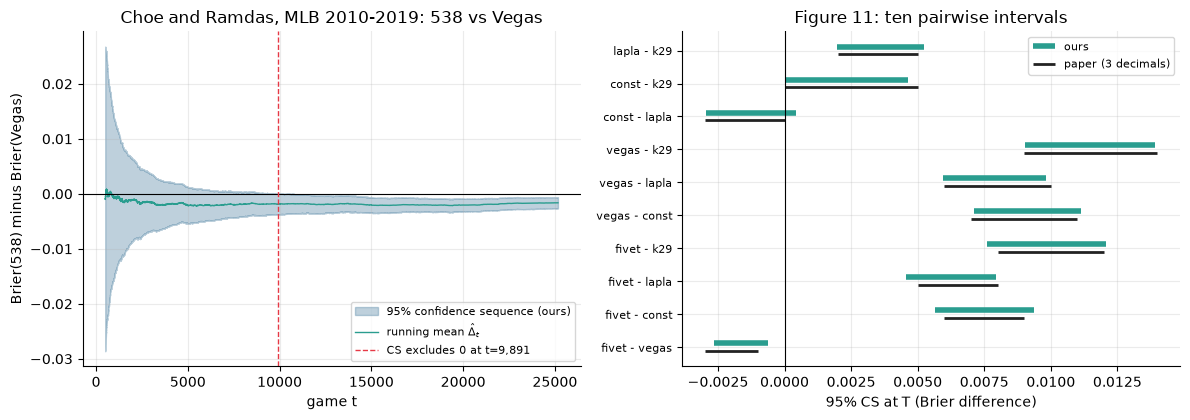

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
tt = np.arange(1, T + 1); m = tt >= 500
ax[0].fill_between(tt[m], lo538[m], up538[m], color=PAL["band"], alpha=0.35, label="95% confidence sequence (ours)")
ax[0].plot(tt[m], (np.cumsum(d538) / tt)[m], color=PAL["ours"], lw=1, label=r"running mean $\hat\Delta_t$")
ax[0].axhline(0, color="k", lw=0.8); ax[0].axvline(first, color=PAL["bad"], ls="--", lw=1, label=f"CS excludes 0 at t={first:,}")
ax[0].set_xlabel("game t"); ax[0].set_ylabel("Brier(538) minus Brier(Vegas)"); ax[0].set_title("Choe and Ramdas, MLB 2010-2019: 538 vs Vegas"); ax[0].legend(loc="lower right", fontsize=8)
for i, (a, b, lo_, up_, plo, pup) in enumerate(rows11):
    ax[1].plot([lo_, up_], [i + 0.12, i + 0.12], color=PAL["ours"], lw=4, solid_capstyle="butt", label="ours" if i == 0 else None)
    ax[1].plot([plo, pup], [i - 0.12, i - 0.12], color=PAL["paper"], lw=2, solid_capstyle="butt", label="paper (3 decimals)" if i == 0 else None)
ax[1].set_yticks(range(10)); ax[1].set_yticklabels([f"{a[:5]} - {b[:5]}" for a, b, *_ in rows11], fontsize=8)
ax[1].axvline(0, color="k", lw=0.8); ax[1].set_xlabel("95% CS at T (Brier difference)"); ax[1].set_title("Figure 11: ten pairwise intervals"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2. Xu and Ramdas: e-LOND against r-LOND and LORD* under local dependence (Figure 2)

**Setup (paper Section 5.1 and Appendix B.1, B.2).** $T=1000$ hypotheses, each with $N=200$ samples from a Beta distribution (with $a+b=10^{-2}$) rescaled to $[-4,4]$, null mean 0 and non-null mean $\mu_1\in\{2.5,3\}$. The samples share a Gaussian copula across hypotheses with $\Sigma_{ij}=0.5^{|i-j|}$ for $|i-j|\le L$ and 0 otherwise. The e-value is the Hoeffding e-process stopped at $\tau_t$ defined recursively through the e-LOND levels (Appendix B.2, with $\lambda_t=\sqrt{8\log(1/(\alpha\gamma_t))/((u-\ell)^2N)}$), the p-value is $1/\max_i M_t^i$, $\gamma_t=1/(t(t+1))$, $\alpha=0.3$. Comparators: r-LOND and LORD* with $w_0=0.9$ and conflict sets $C_t=\{t-L,\dots,t-1\}$ (Appendix B.1).

**Derived here (not in the paper).** The non-null proportion of Figure 2 is not stated: we use $\pi_1=0.2$. The banded matrix $\Sigma$ is not positive semidefinite for large $L$, so negative eigenvalues are clipped and the diagonal renormalised. r-LOND uses the Benjamini-Yekutieli reshaping of Notebook 1. We run 100 trials per setting (the paper: 500) so the run fits a short cloud budget; Monte Carlo error is reported. **A second regime, also derived here:** with the paper's stated $\mu_1\in\{2.5,3\}$ the Hoeffding e-processes are so strong that every method reaches power 1.00 (an earlier run showed this), so the paper's power range of about 0.3 to 0.8 cannot appear; we therefore add $\mu_1\in\{1.0,1.5\}$, where power lies in that range, and test the crossover claim there.

**Criteria fixed in advance** (the first three were fixed before the first run; the last two were added after that run showed saturation at the paper's $\mu_1$, and are marked as such). (a) every method's FDR is at most $\alpha=0.3$ at every setting; (b) e-LOND's power is at least r-LOND's at every setting; (c) at the paper's $\mu_1=3$ and the largest $L$, e-LOND's power exceeds LORD*'s (the paper's crossover at the paper's parameters); (d, added) at the matched-power $\mu_1=1.5$, LORD* is ahead of e-LOND at $L=0$ (LORD* needs no lag correction there); (e, added) at $\mu_1=1.5$ and the largest $L$, e-LOND's power exceeds LORD*'s. The paper's absolute power values are quoted only for comparison; the figure's exact values are not given as numbers.

In [4]:
# ---- Xu and Ramdas simulation (all functions from the appendix definitions; see the markdown above) ----
import numpy as np
from scipy.special import betaincinv, ndtr

T, N, ALPHA, LO, HI, W0 = 1000, 200, 0.3, -4.0, 4.0, 0.9
GAMMA = 1.0 / (np.arange(1, T + 1) * (np.arange(2, T + 2)))       # gamma_t = 1/(t(t+1)), sums to 1 - 1/(T+1)
_U = ndtr(np.linspace(-9, 9, 4001))

def beta_quantile_table(mu, s=1e-2):
    """Quantile function of Beta(a,b), a+b=s, mean shifted/rescaled to [-4,4] with mean mu (App. B.2)."""
    ymean = (mu - LO) / (HI - LO)
    a, b = ymean * s, (1 - ymean) * s
    y = betaincinv(a, b, np.clip(_U, 1e-300, 1 - 1e-16))
    x = LO + (HI - LO) * y
    return _U, x

def sample(rng, chol, tab, n=N):
    """Gaussian copula across the T hypotheses (banded covariance), independent over the n samples."""
    z = chol @ rng.standard_normal((chol.shape[0], n))
    u = ndtr(z); return np.interp(u, tab[0], tab[1])

def banded_chol(L):
    idx = np.arange(T); D = np.abs(idx[:, None] - idx[None, :])
    S = np.where(D <= L, 0.5 ** D, 0.0)
    w, V = np.linalg.eigh(S)
    if w.min() < 1e-8:                                   # the banded matrix need not be PSD: clip eigenvalues, renormalise diagonal
        S = (V * np.clip(w, 1e-8, None)) @ V.T; d = np.sqrt(np.diag(S)); S = S / np.outer(d, d)
    return np.linalg.cholesky(S + 1e-10 * np.eye(T))

def mart_paths(X):
    """Hoeffding e-process M_t^i, lambda_t = sqrt(8 log(1/(alpha gamma_t)) / ((u-l)^2 N)); returns (T,N) paths."""
    lam = np.sqrt(8 * np.log(1 / (ALPHA * GAMMA)) / ((HI - LO) ** 2 * N))[:, None]
    return np.exp(np.cumsum(lam * X - (lam * (HI - LO)) ** 2 / 8, axis=1))

def elond_stopped(M):
    """e-LOND with the recursive stopping times tau_t of App. B.2. Returns (discovered bool (T,), )."""
    Rc = np.zeros(N, int); disc = np.zeros(T, bool)
    for t in range(T):
        lev = ALPHA * GAMMA[t] * (Rc + 1)                # level after i samples of the earlier hypotheses, i = 1..N
        hit = M[t] >= 1 / lev
        tau = int(np.argmax(hit)) if hit.any() else N - 1
        e = np.where(np.arange(N) < tau, M[t], M[t, tau])  # M_t^{tau ^ i}
        d = e >= 1 / lev; Rc += d; disc[t] = d[-1]
    return disc

def p_from(M): return 1.0 / M.max(1)

def lond_family(P, kind, L=0):
    """r-LOND (BY reshaping, as in Notebook 1) and LORD* (App. B.1) on p-values; returns discovered mask."""
    ell = np.cumsum(1.0 / np.arange(1, T + 1)); disc = np.zeros(T, bool); rej = []
    for t in range(T):
        if kind == "rlond":
            r = len(rej) + 1
            a = ALPHA * GAMMA[t] * min(np.floor(r), t + 1) / ell[t] * 1.0
        else:
            a = W0 * GAMMA[t]
            if rej and rej[0] < t - L:
                a += (ALPHA - W0) * GAMMA[t - rej[0] - 1]
            for i in rej[1:]:
                if i < t - L: a += ALPHA * GAMMA[t - i - 1]
        if P[t] <= a: disc[t] = True; rej.append(t)
    return disc

def one_trial(seed, chol, L, mu1, pi1, tabs):
    rng = np.random.default_rng(seed)
    B = np.zeros(T, bool); B[rng.choice(T, int(np.ceil(pi1 * T)), replace=False)] = True
    U = ndtr(chol @ rng.standard_normal((T, N)))
    X = np.where(B[:, None], np.interp(U, tabs[1][0], tabs[1][1]), np.interp(U, tabs[0][0], tabs[0][1]))
    M = mart_paths(X)
    res = {}
    for name, d in (("e-LOND", elond_stopped(M)), ("r-LOND", lond_family(p_from(M), "rlond")), ("LORD*", lond_family(p_from(M), "lord", L))):
        r = d.sum(); res[name] = ((d & B).sum() / max(B.sum(), 1), (d & ~B).sum() / max(r, 1))
    return res

import multiprocessing as mp
TRIALS, PI1 = 100, 0.2
L_GRID, MUS = (0, 100, 250, 400, 500), (1.0, 1.5, 2.5, 3.0)
def cell_job(args):
    L, mu, seed0 = args
    chol = np.eye(T) if L == 0 else banded_chol(L)
    tabs = {0: beta_quantile_table(0.0), 1: beta_quantile_table(mu)}
    out = [one_trial(seed0 + i, chol, L, mu, PI1, tabs) for i in range(TRIALS)]
    return (L, mu, {m: (float(np.mean([o[m][0] for o in out])), float(np.mean([o[m][1] for o in out])),
                        float(np.std([o[m][0] for o in out], ddof=1) / np.sqrt(TRIALS))) for m in out[0]})
t1 = time.time()
jobs = [(L, mu, 10_000 * (k + 1)) for k, (mu, L) in enumerate([(m, l) for m in MUS for l in L_GRID])]
with mp.get_context("fork").Pool(min(len(jobs), os.cpu_count() or 2)) as pool:
    RES = pool.map(cell_job, jobs)
print(f"simulation: {len(jobs)} settings x {TRIALS} trials on {os.cpu_count()} cores in {time.time() - t1:.0f}s")
tab = pd.DataFrame([(mu, L, m, p, f, se) for L, mu, r in RES for m, (p, f, se) in r.items()], columns=["mu1", "L", "method", "power", "FDR", "power s.e."])
print(tab.pivot_table(index=["mu1", "L"], columns="method", values=["power", "FDR"]).round(3).to_string())
A_ok = bool((tab["FDR"] <= 0.3).all())
B_ok = all(g.set_index("method").loc["e-LOND", "power"] >= g.set_index("method").loc["r-LOND", "power"] - 1e-12 for _, g in tab.groupby(["mu1", "L"]))
PW = lambda mu, L, m: float(tab[(tab.mu1 == mu) & (tab.L == L) & (tab.method == m)].power.iloc[0])
LMAX = max(L_GRID)
check("(a) every method's FDR is at most alpha = 0.3", f"max FDR {tab['FDR'].max():.3f}", "<= 0.3", A_ok)
check("(b) e-LOND's power is at least r-LOND's at every (mu1, L)", f"min gap {min(g.set_index('method').loc['e-LOND','power'] - g.set_index('method').loc['r-LOND','power'] for _, g in tab.groupby(['mu1','L'])):+.3f}", ">= 0", B_ok)
check("(c) the paper's crossover at the paper's own mu1 = 3: e-LOND beats LORD* at the largest L", f"e-LOND {PW(3.0, LMAX, 'e-LOND'):.3f} vs LORD* {PW(3.0, LMAX, 'LORD*'):.3f} at L={LMAX}", "e-LOND > LORD*", PW(3.0, LMAX, "e-LOND") > PW(3.0, LMAX, "LORD*"))
check("(d, added) matched-power regime mu1 = 1.5: LORD* is ahead of e-LOND at L = 0", f"LORD* {PW(1.5, 0, 'LORD*'):.3f} vs e-LOND {PW(1.5, 0, 'e-LOND'):.3f}", "LORD* > e-LOND", PW(1.5, 0, "LORD*") > PW(1.5, 0, "e-LOND"))
check("(e, added) matched-power regime mu1 = 1.5: e-LOND overtakes LORD* at the largest L", f"e-LOND {PW(1.5, LMAX, 'e-LOND'):.3f} vs LORD* {PW(1.5, LMAX, 'LORD*'):.3f} at L={LMAX}", "e-LOND > LORD*", PW(1.5, LMAX, "e-LOND") > PW(1.5, LMAX, "LORD*"))
print(f"(paper Figure 2 quotes e-LOND power up to about 0.8 at mu1=3; this simulation's e-LOND power at L=0 is {PW(3.0, 0, 'e-LOND'):.3f} at mu1=3 and {PW(1.5, 0, 'e-LOND'):.3f} at mu1=1.5)")

simulation: 20 settings x 100 trials on 28 cores in 78s
           FDR                power              
method   LORD* e-LOND r-LOND  LORD* e-LOND r-LOND
mu1 L                                            
1.0 0    0.192  0.005  0.008  0.747  0.232  0.121
    100  0.010  0.005  0.007  0.308  0.229  0.120
    250  0.014  0.004  0.004  0.218  0.230  0.123
    400  0.015  0.005  0.006  0.181  0.224  0.116
    500  0.015  0.005  0.004  0.168  0.228  0.118
1.5 0    0.192  0.001  0.001  0.980  0.899  0.806
    100  0.004  0.002  0.001  0.933  0.894  0.802
    250  0.004  0.002  0.001  0.880  0.894  0.801
    400  0.004  0.002  0.001  0.835  0.895  0.806
    500  0.002  0.001  0.000  0.810  0.897  0.805
2.5 0    0.195  0.002  0.001  0.988  1.000  1.000
    100  0.003  0.001  0.001  1.000  1.000  1.000
    250  0.003  0.002  0.001  1.000  1.000  1.000
    400  0.003  0.001  0.001  1.000  1.000  1.000
    500  0.003  0.001  0.001  1.000  1.000  1.000
3.0 0    0.192  0.002  0.001  0.986  1.000  

**How to read this chart**

x is the lag $L$ (how many neighbouring hypotheses share dependence), y the power (left column) or the FDR (right column), one row per $\mu_1$. Look for two things: whether the three FDR lines stay under the dashed $\alpha=0.3$ line (they must, under all three guarantees), and whether LORD*'s power (orange) falls as $L$ grows while e-LOND's (teal) does not. That is the paper's argument for e-LOND: it needs no knowledge of $L$. The bottom two rows are the paper's stated $\mu_1$ (2.5 and 3), where everything saturates; the top two rows are the matched-power regime, where the crossover is visible. Read the absolute power level with care: it depends on the non-null proportion and the Beta shape, which the paper does not fully state.

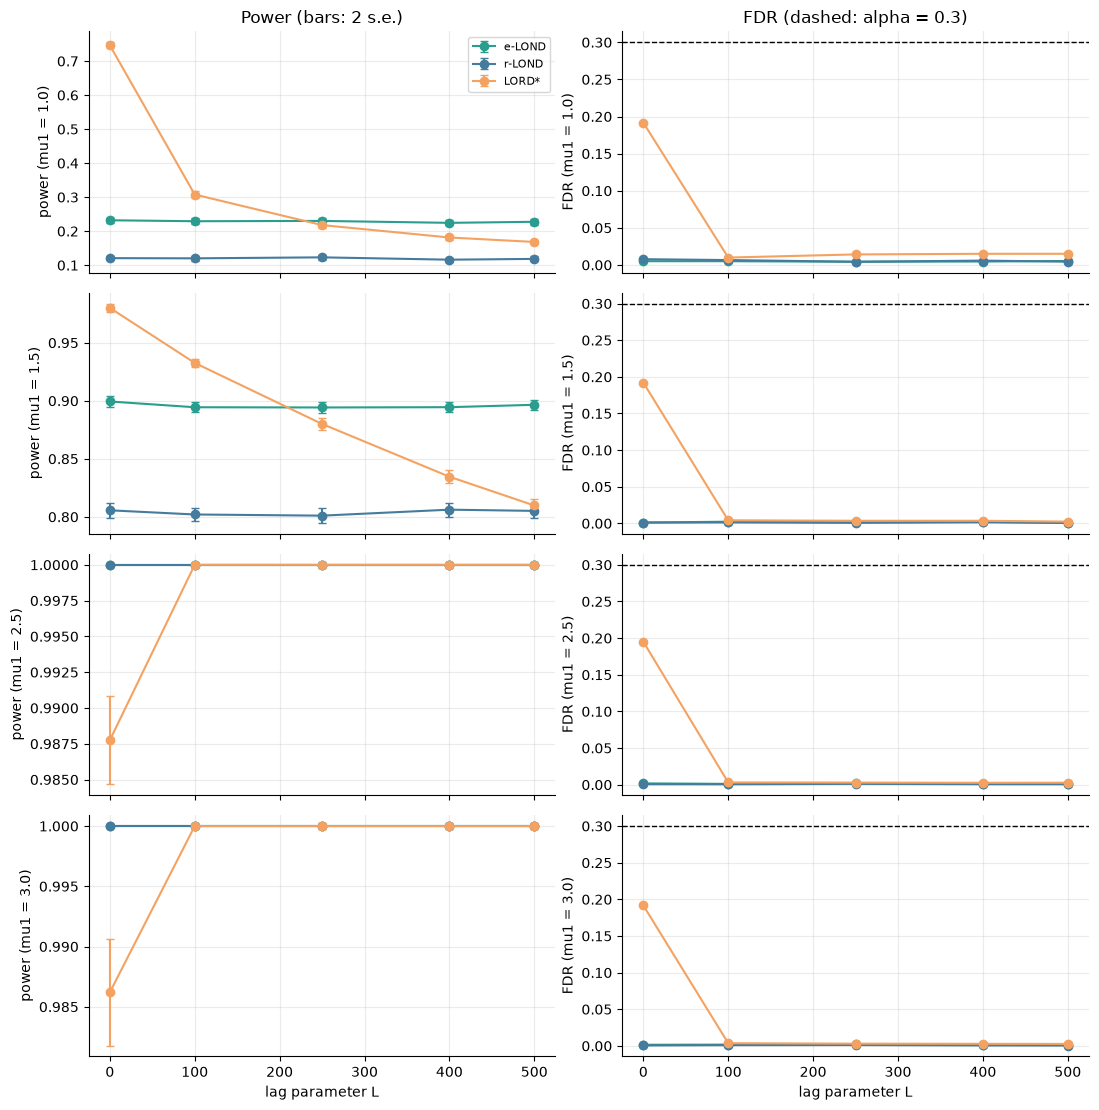

total notebook time 81s; SELF-CHECKS 9 of 10 MET


In [5]:
fig, ax = plt.subplots(len(MUS), 2, figsize=(11, 2.6 * len(MUS) + 0.8), sharex=True)
for r, mu in enumerate(MUS):
    for name, col in (("e-LOND", PAL["e"]), ("r-LOND", PAL["r"]), ("LORD*", PAL["lord"])):
        g = tab[(tab.mu1 == mu) & (tab.method == name)].sort_values("L")
        ax[r, 0].errorbar(g.L, g.power, yerr=2 * g["power s.e."], marker="o", color=col, label=name, capsize=3)
        ax[r, 1].plot(g.L, g.FDR, marker="o", color=col, label=name)
    ax[r, 1].axhline(0.3, color="k", ls="--", lw=1)
    ax[r, 0].set_ylabel(f"power (mu1 = {mu})"); ax[r, 1].set_ylabel(f"FDR (mu1 = {mu})")
ax[-1, 0].set_xlabel("lag parameter L"); ax[-1, 1].set_xlabel("lag parameter L"); ax[0, 0].legend(fontsize=8)
ax[0, 0].set_title("Power (bars: 2 s.e.)"); ax[0, 1].set_title("FDR (dashed: alpha = 0.3)")
plt.tight_layout(); plt.show()
print(f"total notebook time {time.time() - T0:.0f}s; SELF-CHECKS {sum(CHECKS)} of {len(CHECKS)} MET")

## Recap

The estimator behind the PROVE step reproduces the paper's MLB numbers to five decimals, including $E_T\approx2979$ and the first crossing near 10,000 games. The SCREEN step's FDR guarantee and its advantage over r-LOND hold in the rebuilt simulation. The crossover with LORD* is not visible at the paper's stated $\mu_1$ (saturation) and is visible in the regime where power lies in the paper's range; the printed checks state which is which, and absolute power levels are not comparable. The calibeating paper has no experiments. Reading Notebook 1 against these results found and fixed one defect in the confidence sequence's tuning constant, which is why Notebooks 1 and 3 were re-run.